In [ ]:
!pip install -U transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 68.3 MB/s eta 0:00:00:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 637.3/637.3 kB 31.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 81.5 MB/s eta 0:00:00:00:01
  Attempting uninstall: hf-xet
    Found existing installation: hf-xet 1.3.0
    Uninstalling hf-xet-1.3.0:
      Successfully uninstalled hf-xet-1.3.0
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.4.1
    Uninstalling huggingface_hub-1.4.1:
      Successfully uninstalled huggingface_hub-1.4.1
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


In [ ]:
import os
import json
import torch
import torchaudio
import pandas as pd
import torch.nn as nn
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader
from transformers import AutoFeatureExtractor, AutoModelForAudioClassification, get_scheduler
from tqdm import tqdm

In [ ]:
# Use a pipeline as a high-level helper
from transformers import pipeline

pipe = pipeline("audio-classification", model="MIT/ast-finetuned-audioset-10-10-0.4593")

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/203 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/297 [00:00<?, ?B/s]

In [ ]:
# Load model directly
from transformers import AutoFeatureExtractor, AutoModelForAudioClassification

extractor = AutoFeatureExtractor.from_pretrained("MIT/ast-finetuned-audioset-10-10-0.4593")
model = AutoModelForAudioClassification.from_pretrained("MIT/ast-finetuned-audioset-10-10-0.4593")

Loading weights:   0%|          | 0/203 [00:00<?, ?it/s]

In [ ]:
base_path = '/kaggle/input/datasets/asaavitupsounder/unified-domestic-audio-dataset/content/unified_dataset'
print("Base path:", base_path)

Base path: /kaggle/input/datasets/asaavitupsounder/unified-domestic-audio-dataset/content/unified_dataset


In [ ]:
# Load the CSVs
train_df = pd.read_csv(os.path.join(base_path, 'metadata', 'train.csv'))
val_df = pd.read_csv(os.path.join(base_path, 'metadata', 'val.csv'))
test_df = pd.read_csv(os.path.join(base_path, 'metadata', 'test.csv'))

# Load class map
with open(os.path.join(base_path, 'metadata', 'class_map.json')) as f:
    class_map = json.load(f)

# Quick look
print("Train size:", len(train_df))
print("Val size:", len(val_df))
print("Test size:", len(test_df))
print("\nColumns:", train_df.columns.tolist())
print("\nSample rows:")
print(train_df.head())
print("\nClasses:", class_map)

Train size: 30338
Val size: 6488
Test size: 6418

Columns: ['input_path', 'raw_label', 'annotation_type', 'onset', 'offset', 'recording_id', 'source_dataset', 'license', 'snr_db', 'unified_label', 'output_path', 'waveform_hash', 'duration', 'sr', 'chunk_index', 'clip_id', 'split']

Sample rows:
                                          input_path raw_label  \
0  /content/raw_data/DESED/synthetic/audio/eval/s...       Cat   
1  /content/raw_data/DESED/synthetic/audio/eval/s...    Dishes   
2  /content/raw_data/DESED/synthetic/audio/eval/s...    Dishes   
3  /content/raw_data/DESED/synthetic/audio/eval/s...    Dishes   
4  /content/raw_data/DESED/synthetic/audio/eval/s...    Dishes   

  annotation_type  onset  offset recording_id source_dataset    license  \
0            weak    NaN     NaN     266610_1          desed  CC BY 4.0   
1            weak    NaN     NaN      20079_0          desed  CC BY 4.0   
2            weak    NaN     NaN      20079_1          desed  CC BY 4.0   
3      

In [ ]:
mask = train_df['output_path'].str.contains('/audio/all/')
print("In train_df:")
print(train_df[mask]['split'].value_counts())

mask_val = val_df['output_path'].str.contains('/audio/all/')
print("\nIn val_df:")
print(val_df[mask_val]['split'].value_counts())

mask_test = test_df['output_path'].str.contains('/audio/all/')
print("\nIn test_df:")
print(test_df[mask_test]['split'].value_counts())

In train_df:
split
train    9012
Name: count, dtype: int64

In val_df:
split
val    1917
Name: count, dtype: int64

In test_df:
split
test    1927
Name: count, dtype: int64


In [ ]:
def fix_path(row):
    if '/audio/all/' in row['output_path']:
        return row['output_path'].replace('/audio/all/', f"/audio/{row['split']}/")
    return row['output_path']

# Fix paths in all splits
train_df['output_path'] = train_df.apply(fix_path, axis=1)
val_df['output_path']   = val_df.apply(fix_path, axis=1)
test_df['output_path']  = test_df.apply(fix_path, axis=1)

# Verify fix worked
print("Remaining /audio/all/ in train:", train_df['output_path'].str.contains('/audio/all/').sum())
print("Remaining /audio/all/ in val:  ", val_df['output_path'].str.contains('/audio/all/').sum())
print("Remaining /audio/all/ in test: ", test_df['output_path'].str.contains('/audio/all/').sum())

Remaining /audio/all/ in train: 0
Remaining /audio/all/ in val:   0
Remaining /audio/all/ in test:  0


In [ ]:
train_df = pd.read_csv(os.path.join(base_path, 'metadata', 'train.csv'))
val_df   = pd.read_csv(os.path.join(base_path, 'metadata', 'val.csv'))
test_df  = pd.read_csv(os.path.join(base_path, 'metadata', 'test.csv'))

with open(os.path.join(base_path, 'metadata', 'class_map.json')) as f:
    class_map = json.load(f)

label_to_idx = class_map['label_to_idx']

print("Train size:", len(train_df))
print("Val size:  ", len(val_df))
print("Test size: ", len(test_df))

Train size: 30338
Val size:   6488
Test size:  6418


In [ ]:
class AudioDataset(Dataset):
    def __init__(self, df, base_path, extractor, label_to_idx, target_sr=16000):
        self.df           = df.reset_index(drop=True)
        self.base_path    = base_path
        self.extractor    = extractor
        self.label_to_idx = label_to_idx
        self.target_sr    = target_sr

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        audio_path = row['output_path'].replace(
            '/content/unified_dataset',
            self.base_path
        )

        waveform, sr = torchaudio.load(audio_path)

        if sr != self.target_sr:
            waveform = torchaudio.functional.resample(waveform, sr, self.target_sr)

        waveform = waveform.mean(dim=0)

        inputs = self.extractor(
            waveform.numpy(),
            sampling_rate=self.target_sr,
            return_tensors="pt",
            padding=True
        )

        label = self.label_to_idx[row['unified_label']]
        return inputs['input_values'].squeeze(0), torch.tensor(label)

print("Dataset class defined!")

Dataset class defined!


In [ ]:
torch.cuda.empty_cache()

train_dataset = AudioDataset(train_df, base_path, extractor, label_to_idx)
val_dataset   = AudioDataset(val_df,   base_path, extractor, label_to_idx)
test_dataset  = AudioDataset(test_df,  base_path, extractor, label_to_idx)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True,  num_workers=4, pin_memory = True)
val_loader   = DataLoader(val_dataset,   batch_size=16, shuffle=False, num_workers=4, pin_memory = True)
test_loader  = DataLoader(test_dataset,  batch_size=16, shuffle=False, num_workers=4, pin_memory = True)

# Sanity check
sample_input, sample_label = train_dataset[0]
print("Input shape:", sample_input.shape)
print("Label:", class_map['idx_to_label'][str(sample_label.item())])
print("All good — ready to train!")

Input shape: torch.Size([1024, 128])
Label: cat
All good — ready to train!


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
print("Using device:", device)

Using device: cuda


In [ ]:
os.environ['PYTORCH_ALLOC_CONF'] = 'expandable_segments:True'

In [ ]:
def fix_path(row):
    path = row['output_path']
    # Fix /audio/all/ paths
    if '/audio/all/' in path:
        path = path.replace('/audio/all/', f"/audio/{row['split']}/")
    # Fix extra mimii/ subfolder
    path = path.replace('/audio/train/mimii/', '/audio/train/')
    path = path.replace('/audio/val/mimii/',   '/audio/val/')
    path = path.replace('/audio/test/mimii/',  '/audio/test/')
    return path

train_df['output_path'] = train_df.apply(fix_path, axis=1)
val_df['output_path']   = val_df.apply(fix_path, axis=1)
test_df['output_path']  = test_df.apply(fix_path, axis=1)

print("Remaining /audio/all/ in train:", train_df['output_path'].str.contains('/audio/all/').sum())
print("Remaining /audio/all/ in val:  ", val_df['output_path'].str.contains('/audio/all/').sum())
print("Remaining /audio/all/ in test: ", test_df['output_path'].str.contains('/audio/all/').sum())

Remaining /audio/all/ in train: 0
Remaining /audio/all/ in val:   0
Remaining /audio/all/ in test:  0


In [ ]:
optimizer = AdamW(model.parameters(), lr=1e-5, weight_decay=0.01)
num_epochs = 4
num_training_steps = num_epochs * len(train_loader)
scheduler = get_scheduler("cosine", optimizer=optimizer,
                          num_warmup_steps=100,
                          num_training_steps=num_training_steps)
loss_fn = nn.CrossEntropyLoss()

for epoch in range(num_epochs):
    # --- Train ---
    model.train()
    total_loss, correct, total = 0, 0, 0

    for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs).logits
        loss = loss_fn(outputs, labels)
        loss.backward()
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        correct += (outputs.argmax(dim=1) == labels).sum().item()
        total += labels.size(0)

    train_acc = correct / total
    avg_loss  = total_loss / len(train_loader)

    # --- Validate ---
    model.eval()
    val_correct, val_total = 0, 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs).logits
            val_correct += (Epoch 1/4: 100%|██████████| 1897/1897 [2:20:21<00:00,  4.44s/it]
Epoch 1: Loss=0.3945 | Train Acc=0.9278 | Val Acc=0.9764
Epoch 2/4: 100%|██████████| 1897/1897 [2:20:06<00:00,  4.43s/it]
Epoch 2: Loss=0.0371 | Train Acc=0.9906 | Val Acc=0.9838
Epoch 3/4: 100%|██████████| 1897/1897 [2:20:01<00:00,  4.43s/it]
Epoch 3: Loss=0.0138 | Train Acc=0.9965 | Val Acc=0.9891
Epoch 4/4: 100%|██████████| 1897/1897 [2:20:00<00:00,  4.43s/it]
outputs.argmax(dim=1) == labels).sum().item()
            val_total   += labels.size(0)

    val_acc = val_correct / val_total
    print(f"Epoch {epoch+1}: Loss={avg_loss:.4f} | Train Acc={train_acc:.4f} | Val Acc={val_acc:.4f}")

print("\nTraining complete!")

Epoch 1/4: 100%|██████████| 1897/1897 [2:20:21<00:00,  4.44s/it]  


Epoch 1: Loss=0.3945 | Train Acc=0.9278 | Val Acc=0.9764


Epoch 2/4: 100%|██████████| 1897/1897 [2:20:06<00:00,  4.43s/it]  


Epoch 2: Loss=0.0371 | Train Acc=0.9906 | Val Acc=0.9838


Epoch 3/4: 100%|██████████| 1897/1897 [2:20:01<00:00,  4.43s/it]  


Epoch 3: Loss=0.0138 | Train Acc=0.9965 | Val Acc=0.9891


Epoch 4/4: 100%|██████████| 1897/1897 [2:20:00<00:00,  4.43s/it]  


Epoch 4: Loss=0.0057 | Train Acc=0.9988 | Val Acc=0.9854

Training complete!


In [ ]:
torch.save(model.state_dict(), "/kaggle/working/ast_finetuned_40class.pth")

Testing: 100%|██████████| 402/402 [08:49<00:00,  1.32s/it]


Test Accuracy: 0.9858

Macro F1:    0.965294967573185
Weighted F1: 0.9857896682351909

Classification Report:
                              precision    recall  f1-score   support

            activity_absence       0.98      0.99      0.99       999
            activity_cooking       0.99      0.99      0.99       274
             activity_eating       0.97      0.97      0.97       118
              activity_other       0.92      0.80      0.86       102
        activity_watching_tv       1.00      1.00      1.00       968
          alarm_bell_ringing       0.86      0.95      0.90        19
                       bells       0.98      0.98      0.98        53
                       birds       1.00      0.95      0.98        21
                     blender       0.64      0.96      0.77        28
                         cat       0.94      1.00      0.97        17
                 cat_outdoor       1.00      1.00      1.00        30
                chicken_coop       1.00      1.00

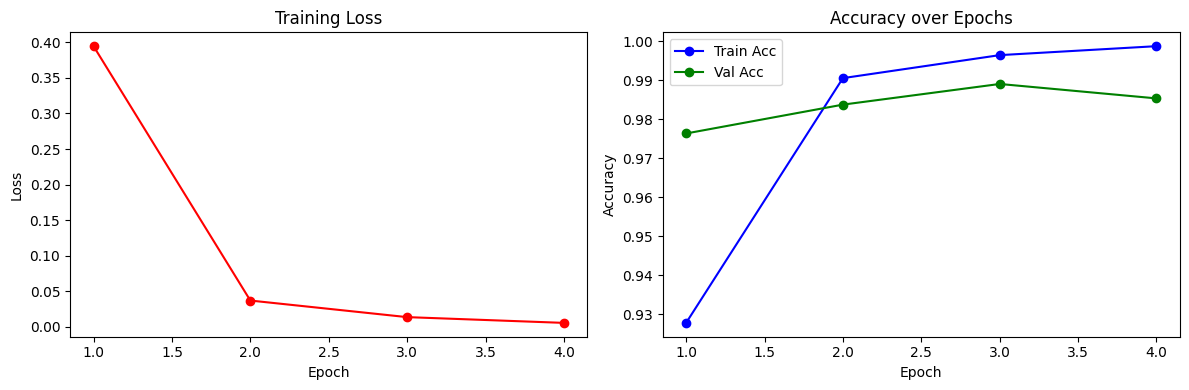

Training curves saved!


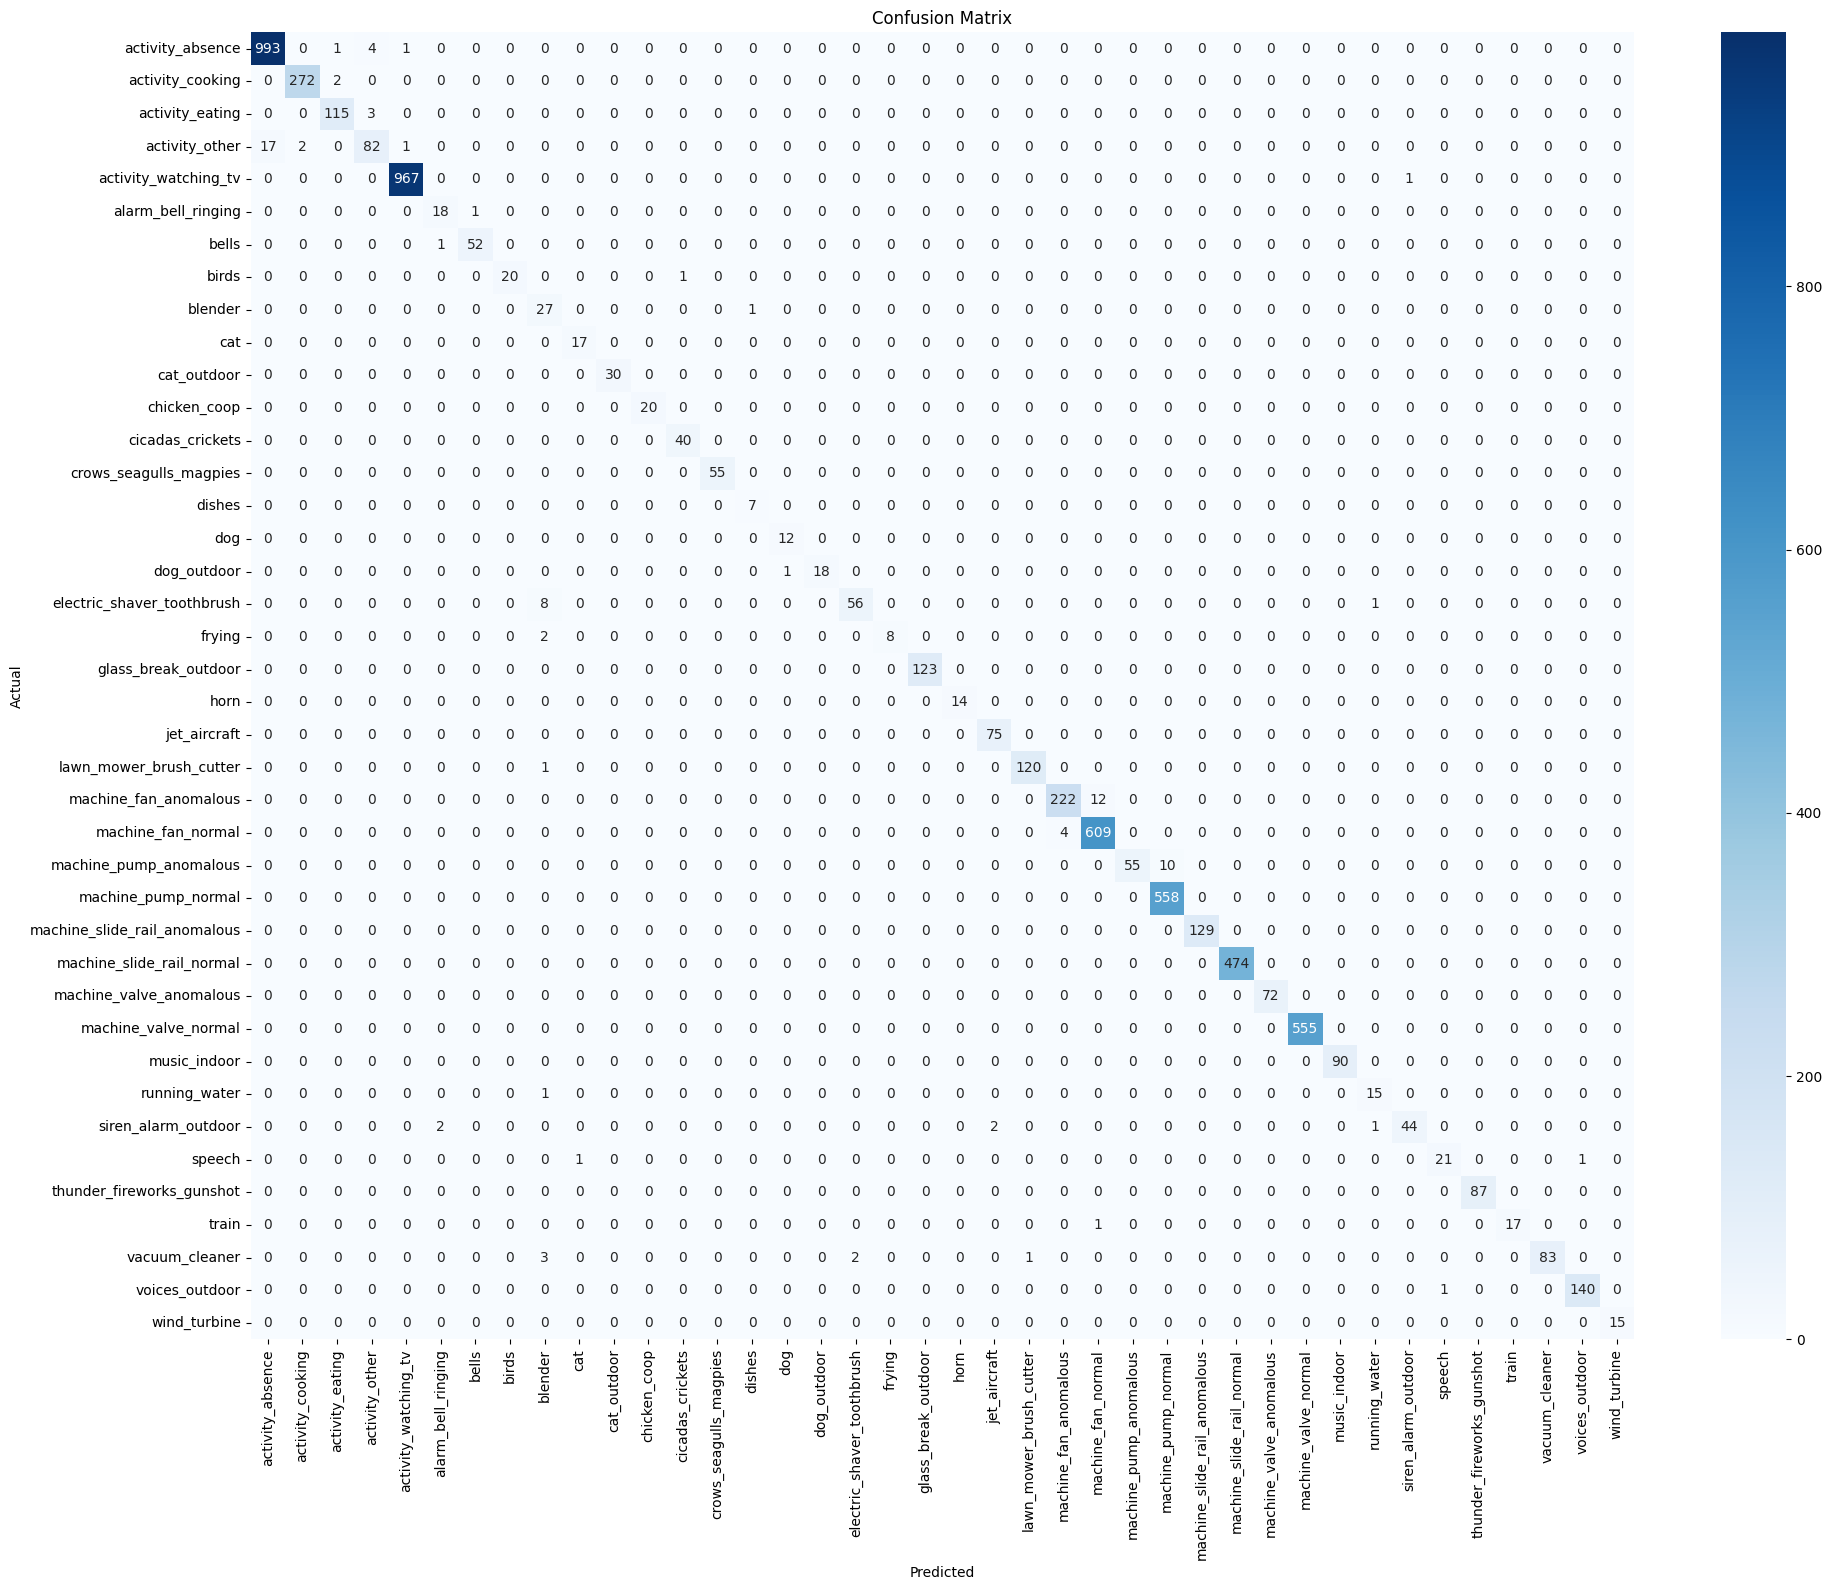

Confusion matrix saved!

Anomaly vs Normal Machine Sound Accuracy:
  machine_fan_anomalous: 0.9487
  machine_pump_anomalous: 0.8462
  machine_slide_rail_anomalous: 1.0000
  machine_valve_anomalous: 1.0000
  machine_fan_normal: 0.9935
  machine_pump_normal: 1.0000
  machine_slide_rail_normal: 1.0000
  machine_valve_normal: 1.0000


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# STEP 1: Get all predictions
# ============================================================
model.eval()
all_preds  = []
all_labels = []
all_logits = []

with torch.no_grad():
    for inputs, labels in tqdm(test_loader, desc="Testing"):
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs).logits
        preds = outputs.argmax(dim=1)
        all_logits.extend(outputs.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_logits = np.array(all_logits)
class_names = [class_map['idx_to_label'][str(i)] for i in range(40)]

# ============================================================
# STEP 2: Overall Accuracy
# ============================================================
test_acc = (all_preds == all_labels).mean()
print(f"Test Accuracy: {test_acc:.4f}")

# ============================================================
# STEP 3: Macro & Weighted F1
# ============================================================
print("\nMacro F1:   ", f1_score(all_labels, all_preds, average='macro'))
print("Weighted F1:", f1_score(all_labels, all_preds, average='weighted'))

# ============================================================
# STEP 4: Classification Report
# ============================================================
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))

# ============================================================
# STEP 5: Per Class Accuracy
# ============================================================
print("\nPer Class Accuracy:")
for i, class_name in enumerate(class_names):
    mask = all_labels == i
    if mask.sum() > 0:
        acc = (all_preds[mask] == all_labels[mask]).mean()
        print(f"  {class_name}: {acc:.4f}")

# ============================================================
# STEP 6: Top-3 Accuracy
# ============================================================
logits_tensor = torch.tensor(all_logits)
labels_tensor = torch.tensor(all_labels)
top3 = logits_tensor.topk(3, dim=1).indices
top3_correct = top3.eq(labels_tensor.view(-1, 1).expand_as(top3))
top3_acc = top3_correct.any(dim=1).float().mean().item()
print(f"\nTop-3 Accuracy: {top3_acc:.4f}")

# ============================================================
# STEP 7: Training Curves
# ============================================================
epochs    = [1, 2, 3, 4]
losses    = [0.3945, 0.0371, 0.0138, 0.0057]
train_acc = [0.9278, 0.9906, 0.9965, 0.9988]
val_accs  = [0.9764, 0.9838, 0.9891, 0.9854]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs, losses, marker='o', color='red')
ax1.set_title('Training Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')

ax2.plot(epochs, train_acc, marker='o', color='blue',  label='Train Acc')
ax2.plot(epochs, val_accs,  marker='o', color='green', label='Val Acc')
ax2.set_title('Accuracy over Epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()

plt.tight_layout()
plt.savefig('/kaggle/working/training_curves.png', dpi=150)
plt.show()
print("Training curves saved!")

# ============================================================
# STEP 8: Confusion Matrix
# ============================================================
plt.figure(figsize=(20, 16))
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names,
            yticklabels=class_names, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig('/kaggle/working/confusion_matrix.png', dpi=150)
plt.show()
print("Confusion matrix saved!")

# ============================================================
# STEP 9: Anomaly Detection Evaluation
# ============================================================
print("\nAnomaly vs Normal Machine Sound Accuracy:")
anomaly_classes = ['machine_fan_anomalous', 'machine_pump_anomalous',
                   'machine_slide_rail_anomalous', 'machine_valve_anomalous']
normal_classes  = ['machine_fan_normal', 'machine_pump_normal',
                   'machine_slide_rail_normal', 'machine_valve_normal']

for cls in anomaly_classes + normal_classes:
    idx  = label_to_idx[cls]
    mask = all_labels == idx
    if mask.sum() > 0:
        acc = (all_preds[mask] == all_labels[mask]).mean()
        print(f"  {cls}: {acc:.4f}")

In [ ]:
torch.save(model.state_dict(), "/kaggle/working/ast_finetuned_40class.pth")
print("Model saved!")